In [1]:
import pandas as pd
import pylab as plt
import seaborn as sns
import numpy as np
pd.options.mode.chained_assignment = None  # default='warn'

sns.set(font_scale=1.2,style="whitegrid")
%matplotlib inline

#Import style guide to make plots
import sys
sys.path.append('../../../../tjn_tools/')

from style_guide import *
#Import some data_processing tools to convert names to ISO3 
from data_processing import *


#Avoid overlapping text|
from adjustText import adjust_text

pd.set_option('display.max_columns', 100)

In [2]:
#Imputation
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

#Linear regression
from sklearn.linear_model import LassoCV, Lasso, LinearRegression 
#Not used, worse: from sklearn.ensemble import GradientBoostingRegressor
#Not used, worse: from sklearn.svm import SVR


#Model selection
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance,plot_partial_dependence


#Main model
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingRegressor


from itertools import permutations, product
from scipy.stats import randint
import pickle

In [3]:
path_files = "../data/raw/"
path_files_final = "../data/final/"
path_files_temp = "../data/processing/"
path_figures = "../results/"


year_cbcr = 2017

In [4]:

#Input from step 1
etr_file = f"{path_files_final}{year_cbcr}_cbcr_etr_rates.xlsx"
df_pairs_file = f"{path_files_final}{year_cbcr}_df_pairs.tsv"
df_fin_file = f"{path_files_final}{year_cbcr}_df_fin.tsv"
d_groups2countries_file = f"{path_files_final}{year_cbcr}_d_groups2countries.dump"
iso3_to_wages_output = f"{path_files_final}{year_cbcr}_iso3_to_wages.dump"
iso3_to_cit_output = f"{path_files_final}{year_cbcr}_iso3_to_cit.dump"

#Output files
final_data_output = f"{path_files_temp}{year_cbcr}_replicates.csv"

iso3_to_count_output = f"{path_files_final}{year_cbcr}_iso3_to_count.dump"
iso3_to_dom_output = f"{path_files_final}{year_cbcr}_iso3_to_dom.dump"


In [5]:
# min_samples_leaf = 20
# learning_rate = 0.2 #0.1
# l2_regularization = 125# 100

#Estimated beloe
metaparameters  = {
    "ln_pi": {'l2_regularization': 158.48931924611142, 'learning_rate': 0.105, 'min_samples_leaf': 20},
    "ln_emp": {'l2_regularization': 100.0, 'learning_rate': 0.16833333333333336, 'min_samples_leaf': 20},
    "ln_revt": {'l2_regularization': 63.09573444801933, 'learning_rate': 0.07333333333333333, 'min_samples_leaf': 20},
    "ln_t_at": {'l2_regularization': 39.810717055349734, 'learning_rate': 0.04166666666666667, 'min_samples_leaf': 20}
}


In [6]:

def impute(df,columns,verbose=0):
    #BayesianRidge performs as well as missForest (R)
    values = df[columns].values
    estimator = BayesianRidge()#(n_estimators=10, random_state=0, bootstrap=True, n_jobs=-1)
    imp = IterativeImputer(max_iter=100, estimator = estimator,verbose=verbose)
    imp.fit(values)
    new_values = imp.transform(values)

    #Replace with full info
    for i,col in enumerate(columns):
        df[col] = new_values[:,i]
    
    return df

# 2. Gravity model for sales, employees and profits

In [7]:
df_etrs = pd.read_excel(etr_file)

In [8]:
df_pairs = pd.read_csv(df_pairs_file,sep="\t")
df_fin =  pd.read_csv(df_fin_file,sep="\t")

d_groups2countries = pickle.load(open(d_groups2countries_file,"rb+"))

In [9]:
df_fin["etr"] = df_fin["txc"]/df_fin['pi']

#ETr by pair of countries
iso3_to_etr_pair = df_fin.set_index(["iso3_o",'iso3_d'])["etr"].to_dict()

In [10]:
# df_fin.loc[df_fin["iso3_o"]=="CHN"].sort_values(by="pi",ascending=False)

### 2.1 Split models by domestic and foreign activities

In [11]:
cols = ['iso3_o','txc','ln_pi', 'ln_emp', 'ln_revt','ln_t_at','ln_cit_revenue_o', 'gdpcap_ppp_o', 'gatt_o', 'wto_o', 'entry_proc_o', 'entry_time_o', 'entry_tp_o', 'Physicians_per_1000_wb_o', 'Nurses_per_1000_wb_o', 'region_tjn_o', 'EU28_o', 'OECD_o', 'UKt_o', 'cit_o', 'ratings_o', 'english_o', 'Total FSI_o', 'ln_accountant_o', 'ln_all_tax_o', 'ln_banker_o', 'ln_ceo_o', 'ln_cfo_o', 'ln_coo_o', 'ln_cxo_o', 'ln_engineer_o', 'ln_other_corporate_o', 'ln_physician_o', 'ln_tax_compliance_audit_o', 'ln_transfer_pricing_o', 'ln_wealth_o', 'ln_audience_o', 'ln_consumption_o', 'ln_gfcf_o', 'ln_population_o', 'ln_uhnwi_o', 'ln_BIS_o', 'ln_finance_o', 'governance_o', 'ln_gdppc_o', 'tax_complex_o', 'cthi_o', 'etr_real_o', 'ln_etr_real_o', 'ln_pop_o', 'ln_gdp_o', 'ln_gdpcap_o', 'ln_gdp_ppp_o', 'ln_pop_pwt_o', 'ln_gdp_ppp_pwt_o', 'ln_entry_cost_o', 'ln_IP_payments_wb_o', 'ln_IP_receipts_wb_o', 'ln_FDI_inflows_WDI_wb_o', 'ln_Total_reserves_wb_o', 'ln_Number_of_new_businesses_registered_wb_o', 'ln_Imports_wb_o', 'ln_Exports_wb_o', 'ln_GDP_pc_wb_o', 'ln_GDP_deflator_wb_o', 'ln_Govt_exp_educ_gdp_wb_o', 'ln_Health_exp_gdp_wb_o', 'ln_GreenfieldFDI_outward_o', 'ln_GreenfieldFDI_inward_o', 'ln_resource_taxes_o', 'ln_total_taxes_revenue_o', 'ln_who_gvt_health_expenditure_o', 'ln_month_wage_o', 'ln_GDP_int_o', 'ln_POP_int_o', 'ln_Physicians_o', 'ln_Nurses_o', 'ln_n_companies_orb_o', 'gdp_ppp_o', 'pop_pwt_o', 'gdp_ppp_pwt_o', 'ln_cit_o']


df_domestic = df_pairs.loc[df_pairs["iso3_o"]==df_pairs["iso3_d"],cols]
df_foreign = df_pairs.loc[df_pairs["iso3_o"]!=df_pairs["iso3_d"]]


In [12]:
for i in df_pairs.count().iteritems():
    if i[1]<2800:
        print(i)

('txc', 2020)
('col_dep_end_year', 666)
('col_dep_end_conflict', 492)
('ln_emp', 1984)
('ln_revt', 2013)
('ln_pi', 1568)
('ln_t_at', 2018)


### 2.2 Find best regularization parameter

In [13]:

scorer = make_scorer(r2_score)

In [14]:

def find_best_model(est,clf,df):
    
    for var in ['ln_pi','ln_emp',"ln_revt","ln_t_at"]:
        df = df.copy().dropna(subset=["ln_pi",var])
        print(var)
        y = df[var].values

        a = df.drop(columns=["txc","ln_pi","ln_emp","ln_revt","ln_t_at"]+[_ for _ in df.columns if "fitted" in _]+[_ for _ in df.columns if "month_wage" in _])
        columns = np.array(a.columns)[a.dtypes!=object]
#         print(columns)
        X = df[columns].values
#         display(df[columns].describe())
        print(y.min(),y.mean(),y.max(),y.std())


        search = clf.fit(X,y)
        print(var, search.best_params_)
        try:
            plt.plot(search.param_grid["alpha"],search.cv_results_["mean_test_score"])
            plt.show()
        except:
            pass
            

### 2.3 Test algorithm
- Out of sample prediction power

In [15]:
def plot_r2(clf,df,var,columns=None):
    df = df.dropna(subset=["ln_pi"]).copy()
    if columns is None:
        a = df.drop(columns=["txc","ln_pi","ln_emp","ln_revt","ln_t_at"]+[_ for _ in df.columns if "fitted" in _]+[_ for _ in df.columns if "month_wage" in _])
        columns = np.array(a.columns)[a.dtypes!=object]

    X = df[columns].values
    y = df[var].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
    
    #return    X_train, X_test, y_train, y_test  
    
    clf.fit(X_train,y_train)
    profits = clf.predict(X_test)
    try:
        print([_ for _ in sorted(zip(clf.coef_,columns)) if _[0]!=0])
    except:
        pass
    plt.plot(np.exp(y_train),np.exp(clf.predict(X_train)),".",color="lightgray")
    plt.plot(np.exp(y_test),np.exp(profits),".")
    plt.xscale("log")
    plt.yscale("log")
    # plt.title(var)
    plt.xlabel("CbCR")
    plt.ylabel("Predicted")
    
    valid = np.isfinite(y_test) & np.isfinite(profits)
#     print(type(y_test),type(profits))
    r2 = r2_score(y_test[valid],profits[valid])
    plt.title("Var: {} R2: {:.2f}".format(var,r2))

    sns.despine(bottom=True,left=True)

### 2.5 Adjust to sum up to totals

In [16]:
def plot_matching_foreign(df_fin,df_foreign,annot=False):
    #What we get vs what we know
    x_fjt = df_fin.loc[df_fin["iso3_d"]=="FJT"].groupby("iso3_o").agg(lambda x: np.sum(x[x>0]))
    x_other = df_fin.loc[(df_fin["iso3_o"]!=df_fin["iso3_d"])&(~df_fin["iso3_o"].isin(x_fjt.index))].groupby("iso3_o").agg(lambda x: np.sum(x[x>0]))
    x = pd.concat([x_fjt,x_other])
    
    a = df_foreign.groupby("iso3_o")["fitted_ln_pi"].agg(lambda x: np.sum(np.exp(x[x>0]))).to_dict()
    x["a"] = x.index.map(a)
    plt.plot(x["pi"],x["a"],"o")
    plt.plot([1E8,1E12],[1E8,1E12],"--",color="gray")
    plt.xscale("log")
    plt.yscale("log")
    if annot:
        for x_,y_,c_ in zip(x["pi"],x["a"],x.index):
            if (x_>0) and (y_>0): 
                plt.annotate(c_,(x_,y_))

    plt.xlabel("Real foreign profits")
    plt.ylabel("Predicted foreign profits")
    sns.despine(bottom=True,left=True)
    plt.show()
    
def adjust_total(c,data):
#     print(c)
    agg_data = df_fin.loc[df_fin["iso3_o"]==c].copy()
    if len(agg_data) == 0:
        return data
    
    if c in ["AUT","SWE","NOR"]:
        agg_data["iso3_d"] = agg_data["iso3_d"].replace("LAC","LAC_sca")
    agg_data = agg_data.set_index("iso3_d")
    

    cs_included = list(agg_data.index)
    for v in ["OAF","OAM","OAS","OTE","AFRIC","ASIAT","EUROP","LAC","LAC_sca","FJT","GRPS"]:
        if v in agg_data.index:
            
            if v == "GRPS":
                cs_group = d_groups2countries[v] - set(cs_included)
                truth_remove = 0
            elif (v == "FJT"): 
                if ("GRPS" in agg_data.index):
                    continue #otherwise fix it with GRPS
                #Countries in the main df but not in the original one and not fixed before = FJT
                cs_group = set(data["iso3_d"])- set(cs_included)
#                 print(cs_group)
                #Remove from FJT everything fixed before
                truth_remove = agg_data.loc[list(set(agg_data.index) - set(["FJT",c])),["revt","emp","pi","t_at"]].sum().fillna(0)

            else:
                cs_included += list(d_groups2countries[v])
                cs_group = d_groups2countries[v] - set(agg_data.index)
                truth_remove = 0

            truth = agg_data.loc[v,["revt","emp","pi","t_at"]] - truth_remove
#             print(v,truth.values)
    
            pred = np.exp(data.loc[data["iso3_d"].isin(cs_group),["fitted_ln_revt","fitted_ln_emp","fitted_ln_pi","fitted_ln_t_at"]])-1
            
            #If profits are negative in the region set them up to 0
            scale_by = pred.sum().values/truth.values
            scale_by[truth.values<0] = np.inf

            

            data.loc[data["iso3_d"].isin(cs_group),["fitted_ln_revt","fitted_ln_emp","fitted_ln_pi","fitted_ln_t_at"]] = np.log(1+pred/scale_by)
#             print((np.exp(data.loc[data["iso3_d"].isin(cs_group),["fitted_ln_revt","fitted_ln_emp","fitted_ln_pi","fitted_ln_t_at"]])-1).sum())
        else: #Countries where no operations
            if v == "GRPS":
                cs_group = d_groups2countries[v] - set(cs_included)
                
                data.loc[data["iso3_d"].isin(cs_group),["fitted_ln_revt","fitted_ln_emp","fitted_ln_pi","fitted_ln_t_at"]] = 0
                
                
    return data


def fill_and_adjust(df_domestic,df_foreign,bootstrap=False,output=False):
    df_domestic = fill_domestic(df_domestic,bootstrap=bootstrap,output=output) #bootstrap this would be a mistake with so few observations
    df_foreign = fill_foreign(df_foreign,bootstrap=bootstrap,output=output)
    if output:
        plot_matching_foreign(df_fin,df_foreign)


    ##Fix the ones we know
    for var in ["ln_pi","ln_revt","ln_emp","ln_t_at"]:
        df_domestic.loc[~np.isnan(df_domestic[var]),"fitted_"+var] = df_domestic.loc[~np.isnan(df_domestic[var]),var] 
        df_foreign.loc[~np.isnan(df_foreign[var]),"fitted_"+var] = df_foreign.loc[~np.isnan(df_foreign[var]),var] 
    
#         df_domestic.loc[df_domestic["ln_n_companies_orb_o"]==0,"fitted_"+var] = 0
#         df_foreign.loc[df_foreign["ln_n_companies_orb_o"]==0,"fitted_"+var] = 0

#     df_domestic.loc[df_domestic["ln_n_companies_orb_o"]==0,"ln_month_wage_o"] = 0
#     df_foreign.loc[df_foreign["ln_n_companies_orb_o"]==0,"ln_month_wage_d"] = 0

    if output:
        plot_matching_foreign(df_fin,df_foreign)

    df_foreign_fixed = [adjust_total(*_) for _ in df_foreign.groupby("iso3_o")]
    df_foreign_fixed = pd.concat(df_foreign_fixed)
#     df_foreign_fixed = df_foreign.copy()
    if output:
        plot_matching_foreign(df_fin,df_foreign_fixed)
    return df_domestic,df_foreign_fixed

### 2.6. Misalignment

In [17]:
def calculate_misalignment(df,
                           weights=[1/2,1/2,0,0],
                           pi_var="pi",
                           weights_var = ["revt","empt","t_at","wages"]):
    """
    Calculate misalignment as a function of sales, employees, capital and wages
    
    In:
    df = data
    pi/rev/emp/cap/wages_var = variables with the profits/revenue/employees/capital/wages (None to discard)
    weights = weights of each of the variables. 
    
    Out:
    
    """
    
    #Make sure it is okay
    assert sum(weights)==1,"Weights need to sum up to 1"
    
    vars_keep = []
    weights_keep = []
    for i,var in enumerate(weights_var):
        if var is None:
            if weights[i] != 0:
                raise(Exception("Weight of None variable is nonzero"))
        else:
            if weights[i] > 0:
                vars_keep.append("share_{}".format(var))
                weights_keep.append(weights[i])
                df["share_{}".format(var)] = df[var]/df[var].sum()
    
#     print(weights_keep)
#     print(vars_keep)
    #Calculate the share of the economy
    df["share_economy"] = (df.loc[:,vars_keep]*weights_keep).sum(1,min_count=len(weights_keep))
    df["share_profits"] = df[pi_var]/df[pi_var].sum()
        
    #Theoretical profits
    df["pi_theo_mis"] = df[pi_var].sum()*df["share_economy"]
    
    #Misalignment
    df["misaligned_profits"] = df[pi_var]-df["pi_theo_mis"]

    #Threshold adjustment
    df.loc[(df["misaligned_profits"]>0)&(df["etr"]>0.25)&(df["Domestic"]==0),"misaligned_profits"] = 0
    #Correct for discrepancies
    x = df["misaligned_profits"]

    pos_pr = x[x>0].sum()
    previous_pr = -x[x<0].sum()
    print("Profit shifted {:2.1f} adjusted to {:2.1f}".format(previous_pr/1E9,pos_pr/1E9))
    df.loc[df["misaligned_profits"]<0,"misaligned_profits"] *= pos_pr/previous_pr



#     df["etr"] = df["p_iso3"].map(iso3_to_etr)
    
    #Total shifted (exclude resource-rich countries)
#     total_shifted = df.loc[(df["misaligned_profits"]>0)&(df["etr"]<0.15),"misaligned_profits"].sum() 
    
    return df


# 3 New model

In [18]:

df_fin_mis = df_fin.loc[df_fin["iso3_d"].apply(get_iso3,print_failure=False).apply(lambda x: isinstance(x,str))]
df_fin_mis["r_iso3"] = df_fin_mis["iso3_o"]
df_fin_mis["p_iso3"] = df_fin_mis["iso3_d"]

In [19]:
#Count of companies (for later)
iso3_to_count = df_fin_mis.loc[df_fin_mis["iso3_o"]!=df_fin_mis["iso3_d"]].groupby("iso3_d")["iso3_o"].count().to_dict()
iso3_to_dom = df_fin_mis.loc[df_fin_mis["iso3_o"]==df_fin_mis["iso3_d"]].groupby("iso3_d")["iso3_o"].count().to_dict()
pickle.dump(iso3_to_count,open(iso3_to_count_output,"wb+"))
pickle.dump(iso3_to_dom,open(iso3_to_dom_output,"wb+"))


In [20]:
df_fin_mis.loc[df_fin_mis["iso3_d"]=="COL"]

,iso3_o,iso3_d,emp,pi,txc,revt,t_at,etr,r_iso3,p_iso3
4,ARG,COL,13.0,3.437554e+06,-1.093620e+05,1.303132e+07,5.763564e+06,-0.031814,ARG,COL
31,AUS,COL,2315.0,-4.592593e+07,7.912334e+06,3.088450e+08,8.686506e+08,-0.172285,AUS,COL
145,BMU,COL,3779.0,9.840933e+07,1.400348e+07,5.361589e+08,3.818772e+08,0.142298,BMU,COL
241,BRA,COL,7708.0,-4.545735e+07,6.031107e+07,6.252241e+09,9.749670e+08,-1.326762,BRA,COL
307,CHE,COL,8842.0,1.255386e+08,9.536980e+07,2.285602e+09,8.437744e+08,0.759685,CHE,COL
440,CHN,COL,1995.0,4.004150e+06,2.398730e+07,4.812031e+08,1.957105e+08,5.990611,CHN,COL
572,DEU,COL,15484.0,9.824162e+07,9.407557e+07,3.210938e+09,1.092963e+09,0.957594,DEU,COL
719,DNK,COL,4000.0,1.740654e+07,1.212599e+07,3.055452e+08,1.263770e+08,0.696634,DNK,COL
836,ESP,COL,51012.0,5.114011e+08,3.007726e+08,7.236148e+09,4.141895e+09,0.588134,ESP,COL
954,FRA,COL,72089.0,2.615722e+08,1.841078e+08,7.419056e+09,2.658709e+09,0.703851,FRA,COL


## Domestic profits

In [21]:
# Domestic profits: Use linear regressin
def fill_domestic(df_domestic,bootstrap=False,output=False,columns=None):
    dfs = []
    for var in ["ln_pi","ln_emp","ln_revt","ln_t_at"]:
        clf = LinearRegression()

        df = df_domestic.dropna(subset=[var]).copy()

        if columns is None:
            columns =["ln_BIS_o","ln_GDP_int_o","ln_POP_int_o","etr_real_o", "cit_o","ln_n_companies_orb_o",]
        
        if bootstrap:
            df = df.loc[df["ln_n_companies_orb_o"]>0].sample(frac=1,replace=True).copy()
        
        X = df.loc[df["ln_n_companies_orb_o"]>0,columns].values
        y = df.loc[df["ln_n_companies_orb_o"]>0,var].values

        clf.fit(X,y)
        if output:
            print(var,r2_score(y,clf.predict(X)))
            d_ = pd.DataFrame(zip(columns,clf.coef_),columns=["index",var])
            d_ = d_.set_index("index")
            dfs.append(d_)

        df_domestic["fitted_{}".format(var)] = clf.predict(df_domestic[columns].values)
        df_domestic.loc[df_domestic["ln_n_companies_orb_o"]==0,"fitted_{}".format(var)] = 0
        df_domestic[var[3:]] = np.exp(df_domestic["fitted_{}".format(var)])-1
    df_domestic["iso3_d"] = df_domestic["iso3_o"] 
    if output:
        display(pd.concat(dfs,axis=1))
    return df_domestic
 

In [52]:
from sklearn.model_selection import cross_validate

for var in ["ln_pi","ln_emp","ln_revt","ln_t_at"]:
    est = LinearRegression()#(alpha=0.03
    df = df_domestic.dropna(subset=[var]).copy()
    print(df.shape)
#     columns = list(set(cols)-set(['iso3_o','region_tjn_o','txc','ln_pi', 'ln_emp', 'ln_revt']))
    
    columns = np.array(df_domestic.columns)[df_domestic.dtypes!=object]
    columns = [_ for _ in columns if (_ not in df_fin.columns) and (_[3:] not in df_fin.columns)]
#     print(len(columns))
    
    df = impute(df,columns)
    
    
    columns =["ln_BIS_o","ln_GDP_int_o","ln_POP_int_o","etr_real_o","ln_n_companies_orb_o"]

    X = df[columns].values
    y = df[var].values
    a = cross_validate(est, X, y,scoring=scorer,cv=10)
    print(var,np.median(a["test_score"]),a["test_score"])

(36, 82)
ln_pi 0.782120445214261 [ 0.70278602  0.96692889  0.9748447   0.60097224  0.57128907  0.89997334
  0.95040374  0.86145487  0.42232677 -7.80215581]
(38, 82)
ln_emp 0.9652400517355241 [0.99753673 0.96691576 0.98262042 0.50484092 0.96356435 0.99150377
 0.93210153 0.9268095  0.97015818 0.39450013]
(38, 82)
ln_revt 0.9302553525323798 [ 0.95703367  0.96540768  0.92518129  0.35215561  0.96434171  0.9641957
  0.81200704  0.60872731  0.93532941 -7.20151441]
(38, 82)
ln_t_at 0.8837958452792668 [ 8.61543157e-01  9.33545470e-01  8.98578354e-01  2.98862244e-03
  8.84409581e-01  9.00191807e-01  8.83182109e-01  9.08682947e-01
 -4.77486946e-01 -1.44396913e+01]


## Foreign profits

In [22]:

# Foreign profits: Use boosting
def fill_foreign(df_foreign,bootstrap=False,output=False,n_repeats=2):
    i = 0
    if output:
        fig = plt.figure(figsize=(18,12))
    for var in ["ln_pi","ln_emp","ln_revt","ln_t_at"]:
        i += 1
        clf = HistGradientBoostingRegressor(**metaparameters[var])

        df = df_foreign.dropna(subset=[var]).copy()
        
        a = df.drop(columns=["txc","ln_pi","ln_emp","ln_revt","ln_t_at"]+[_ for _ in df.columns if "fitted" in _]+[_ for _ in df.columns if "month_wage" in _])
        columns = np.array(a.columns)[a.dtypes!=object]
#         print(columns)
        if bootstrap:
            df = df.sample(frac=1,replace=True)

        X = df[columns].values
        y = df[var].values

        clf.fit(X,y)
        df_foreign.loc[:,"fitted_{}".format(var)] = clf.predict(df_foreign[columns].values)
        

        if output:
            try:
                print([_ for _ in sorted(zip(clf.coef_,columns)) if _[0]!=0])
            except:
                pass
            result = permutation_importance(clf, X, y, n_repeats=n_repeats,
                                            random_state=42, n_jobs=1, scoring=scorer)
            sorted_idx = result.importances_mean.argsort()

            plt.subplot(1,3,i)
            sorted_idx = result.importances_mean.argsort()
            vals = 40
            labels = columns[sorted_idx][-vals:]
            labels = [_[-20:] for _ in labels] #cut if too long
            plt.boxplot(100*result.importances[sorted_idx].T[:,-vals:],
                       vert=False, labels=labels)
            plt.xlabel("Decrease in R2 (% points)")
            plt.title("{}".format(var))
            sns.despine(bottom=True,left=True)
            plt.xscale("log")
            #plt.xticks(rotation=90)

        
    if output:
        plt.tight_layout()
        plt.savefig("./Figures_Hines/permutation_estimation.pdf",bbox_inches="tight")
        #     plt.ylabel("Features")
        plt.show()
    return df_foreign

In [41]:
#Estimate the metaparameters
if 0:
    distributions = dict(learning_rate=np.linspace(0.01,0.2,7),
                                     l2_regularization=np.logspace(1,3,11),
                                    min_samples_leaf=[20],
                                   )
    est = HistGradientBoostingRegressor(random_state=0)

    clf = GridSearchCV(est, distributions, n_jobs=-1, cv=5,verbose=5, scoring=scorer)

    find_best_model(est,clf,df_foreign.dropna(subset=["ln_pi"]))

ln_pi
1.0606245069840958 17.59231257906858 25.520864663995567 3.5843256840633226
Fitting 5 folds for each of 77 candidates, totalling 385 fits
ln_pi {'l2_regularization': 158.48931924611142, 'learning_rate': 0.105, 'min_samples_leaf': 20}
ln_emp
1.0606245069840958 7.575363781115918 14.213047580472887 2.78944068103784
Fitting 5 folds for each of 77 candidates, totalling 385 fits
ln_emp {'l2_regularization': 100.0, 'learning_rate': 0.16833333333333336, 'min_samples_leaf': 20}
ln_revt
1.0606245069840958 19.680031473716173 27.395613305377776 4.004844320358922
Fitting 5 folds for each of 77 candidates, totalling 385 fits
ln_revt {'l2_regularization': 63.09573444801933, 'learning_rate': 0.07333333333333333, 'min_samples_leaf': 20}
ln_t_at
1.0606245069840958 18.865001192786206 26.778107959639502 4.338483303344182
Fitting 5 folds for each of 77 candidates, totalling 385 fits
ln_t_at {'l2_regularization': 39.810717055349734, 'learning_rate': 0.04166666666666667, 'min_samples_leaf': 20}


1500 212
ln_pi
1.0606245069840958 17.64000584445973 25.520864663995567 3.5316937975346145
Fitting 5 folds for each of 22 candidates, totalling 110 fits


C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6492.303538531903, tolerance: 1.8709291619316706
  model = cd_fast.enet_coordinate_descent(


ln_pi {'alpha': 1.9306977288832496}


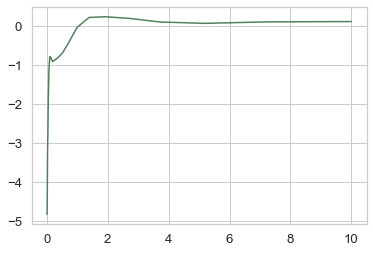

ln_emp
1.0606245069840958 7.5826740224533715 14.213047580472887 2.7867036060716273
Fitting 5 folds for each of 22 candidates, totalling 110 fits


C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3604.042514236763, tolerance: 1.1648575482138916
  model = cd_fast.enet_coordinate_descent(


ln_emp {'alpha': 1.3894954943731375}


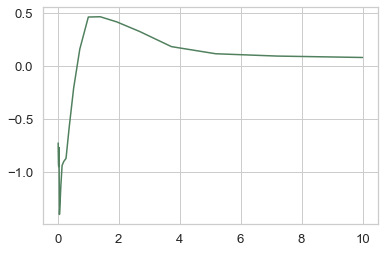

ln_revt
1.0606245069840958 19.67959770040348 27.395613305377776 4.006143796958428
Fitting 5 folds for each of 22 candidates, totalling 110 fits


C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 8315.967438284351, tolerance: 2.407378218286274
  model = cd_fast.enet_coordinate_descent(


ln_revt {'alpha': 1.9306977288832496}


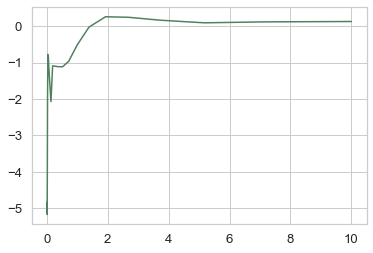

ln_t_at
1.0606245069840958 18.865001192786206 26.778107959639502 4.338483303344182
Fitting 5 folds for each of 22 candidates, totalling 110 fits


C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 10870.34478901623, tolerance: 2.8233656060094363
  model = cd_fast.enet_coordinate_descent(


ln_t_at {'alpha': 2.6826957952797246}


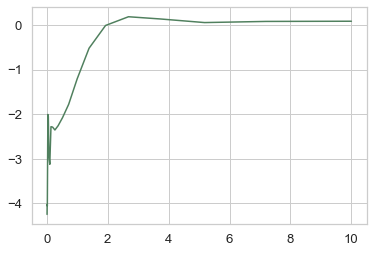

In [42]:
if 0:
#     fill missing (very few values coming from the distancefile only)
    columns = np.array(df_foreign.columns)[df_foreign.dtypes!=object]
    columns = [_ for _ in columns if (_ not in df_fin.columns) and (_[3:] not in df_fin.columns)]

    #The imputing part is very slow
#     df_foreign2 = impute(df_foreign,columns)

#     df_foreign2 = df_foreign.dropna(subset=["ln_pi"])
    x = df_foreign2.count()
    cols = list(x[x>800].index)
    df_foreign2 = df_foreign2.dropna(subset=cols)[cols+["ln_pi","ln_emp","ln_revt","ln_t_at"]]
    print(len(df_foreign2),len(cols))
    
    distributions = dict(alpha=np.logspace(-2,1,22)
                                   )
    est = Lasso()

    clf = GridSearchCV(est, distributions, n_jobs=-1, cv=5,verbose=5,
                                        scoring=scorer)

    find_best_model(est,clf,df_foreign2.dropna(subset=["ln_pi","ln_revt","ln_t_at","ln_emp"]))

C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5725.199834601216, tolerance: 1.630407508154024
  model = cd_fast.enet_coordinate_descent(
C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5195.0506341180135, tolerance: 1.4990438501975074
  model = cd_fast.enet_coordinate_descent(
C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5289.425246195937, tolerance: 1.5222387432766036
  model = cd_fast.enet_coordinate_descent(
C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_c

ln_pi 0.23085517972900432 0.22130973857009054 [ 0.44794733 -0.13962956  0.41533     0.22130974  0.20931839]


C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2972.5855481715366, tolerance: 0.9493150884645669
  model = cd_fast.enet_coordinate_descent(
C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2902.948647328531, tolerance: 0.9391281999902765
  model = cd_fast.enet_coordinate_descent(
C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2874.1990277133973, tolerance: 0.9200055670744193
  model = cd_fast.enet_coordinate_descent(
C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\

ln_emp 0.46710632800070345 0.4853517442192095 [0.55597936 0.48535174 0.56383177 0.26801022 0.46235855]


C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7427.798775436342, tolerance: 2.1463716823663526
  model = cd_fast.enet_coordinate_descent(
C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6808.135047746404, tolerance: 1.9933191643693347
  model = cd_fast.enet_coordinate_descent(
C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6928.201967976079, tolerance: 1.9867505783587314
  model = cd_fast.enet_coordinate_descent(
C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_c

...

C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9386.803195758735, tolerance: 2.460359765746454
  model = cd_fast.enet_coordinate_descent(
C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 8855.971252301435, tolerance: 2.293002691793579
  model = cd_fast.enet_coordinate_descent(
C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 8802.988593651211, tolerance: 2.2813095384404103
  model = cd_fast.enet_coordinate_descent(
C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coo

ln_t_at 0.18553348414662216 0.2390903455361962 [ 0.3504297  -0.06825556  0.3376475   0.06875543  0.23909035]
[(-0.002950266694072967, 'ln_resource_taxes_o'), (-0.0006553000224545934, 'sever_year'), (-0.0004957447895743514, 'tax_complex_o'), (-0.00038347235624271213, 'ln_resource_revenue_d'), (-0.00020015018414531216, 'distwces'), (-0.00011451897873298134, 'iso3num_o'), (-0.00010993061721066956, 'distcap'), (-8.07848175220337e-07, 'pop_pwt_o'), (-4.03862521328165e-08, 'tradeflow_comtrade_o'), (-1.571496574032904e-08, 'tradeflow_imf_d'), (-1.2139613448519608e-20, 'ln_dClaims'), (-4.350711036690524e-22, 'ratings_d'), (-1.0478758566163518e-22, 'ln_cit_revenue_d'), (-1.0675537105878169e-32, 'ln_Total_reserves_wb_d'), (-2.4617176709968946e-33, 'ln_uhnwi_d'), (-6.128551865796081e-34, 'cthi_d'), (-4.001177591174006e-34, 'tax_complex_d'), (-3.4357538236293028e-34, 'ln_dLiabilities'), (-3.093789936635115e-34, 'ln_finance_d'), (-1.804530455385212e-34, 'ln_consumption_d'), (-1.5554194940449765e-34

C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2093.028595380956, tolerance: 0.7172635128271246
  model = cd_fast.enet_coordinate_descent(
C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4932.86242281321, tolerance: 1.4518806665835462
  model = cd_fast.enet_coordinate_descent(


[(-0.0032240179186600756, 'ln_resource_revenue_o'), (-0.0019642575555838754, 'sever_year'), (-0.0009383800680346583, 'iso3num_o'), (-0.0006046848894412649, 'ln_resource_taxes_o'), (-0.0005424783337265256, 'distcap'), (-0.00020534292033703788, 'iso3num_d'), (-8.204459684105554e-05, 'col_dep_end_conflict'), (-6.500094974237136e-05, 'distwces'), (-1.1237256967756132e-06, 'pop_pwt_o'), (-8.585775688924627e-08, 'tradeflow_imf_o'), (-1.9194974831755486e-11, 'tradeflow_baci'), (-1.8498476207954137e-22, 'ratings_d'), (-2.89441738201446e-33, 'ln_population_d'), (-2.4125263916092274e-33, 'ln_BIS_d'), (-7.3144844803226515e-34, 'Total FSI_d'), (-5.3571343687814245e-34, 'ln_accountant_d'), (-2.1475004411355392e-34, 'ln_wealth_d'), (-8.701263331501641e-35, 'ln_physician_d'), (-7.191731508246061e-35, 'ln_engineer_d'), (-4.142256503339956e-35, 'ln_cfo_d'), (-1.912290980015928e-35, 'ln_gfcf_d'), (-1.2433903365240626e-35, 'ln_cxo_d'), (-9.570890886594423e-37, 'ln_ceo_d'), (4.469140052619578e-36, 'ln_all

C:\Users\javga\Anaconda3\envs\oecd\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:530: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6681.874544435153, tolerance: 1.8036067996475984
  model = cd_fast.enet_coordinate_descent(


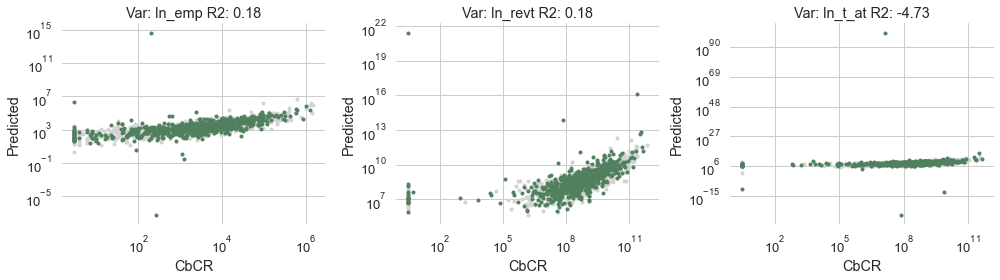

In [47]:
if 0:
    d_lasso = {"ln_pi": 1.9306977288832496,
              "ln_emp":  1.3894954943731375,
              "ln_revt": 1.9306977288832496,
              "ln_t_at": 2.6826957952797246}

    for var in ["ln_pi","ln_emp","ln_revt","ln_t_at"]:
        est = Lasso(alpha=d_lasso[var])
        df = df_foreign2.dropna(subset=[var]).copy()

        a = df.drop(columns=["txc","ln_pi","ln_emp","ln_revt","ln_t_at"]+[_ for _ in df.columns if "fitted" in _]+[_ for _ in df.columns if "month_wage" in _])
        columns = np.array(a.columns)[a.dtypes!=object]


        X = df[columns].values
        y = df[var].values
        a = cross_validate(est, X, y,scoring=scorer,cv=5)
        print(var,np.mean(a["test_score"]),np.median(a["test_score"]),a["test_score"])

    
    
    plt.figure(figsize=(14,4))
    for i,var in enumerate(["ln_emp","ln_revt","ln_t_at"]):
        est = Lasso(d_lasso[var])
        plt.subplot(1,3,i+1)
        plot_r2(est,df_foreign.dropna(subset=[var]),var)

    plt.tight_layout() 
    plt.savefig(f"{path_figures}/predicted_emp_revt_lasso.pdf")

In [48]:
for var in ["ln_pi","ln_emp","ln_revt","ln_t_at"]:
    est = HistGradientBoostingRegressor(**metaparameters[var])#(alpha=0.03)
    df = df_foreign.dropna(subset=[var]).copy()

    a = df.drop(columns=["txc","ln_pi","ln_emp","ln_revt","ln_t_at"]+[_ for _ in df.columns if "fitted" in _]+[_ for _ in df.columns if "month_wage" in _])
    columns = np.array(a.columns)[a.dtypes!=object]


    X = df[columns].values
    y = df[var].values
    a = cross_validate(est, X, y,scoring=scorer,cv=5)
    print(np.mean(a["test_score"]),np.median(a["test_score"]),a["test_score"])


0.4864233779609558 0.5042587703503312 [0.60617248 0.50425877 0.5411567  0.39256068 0.38796825]
0.6001554150864434 0.6449800906654353 [0.70057638 0.64498009 0.6516229  0.50258595 0.50101175]
0.4447808521415778 0.42334003176130364 [0.61132104 0.4909072  0.42334003 0.38481789 0.3135181 ]
0.3996357454261638 0.3947552754729705 [0.48526202 0.40104675 0.39475528 0.38637466 0.33074002]


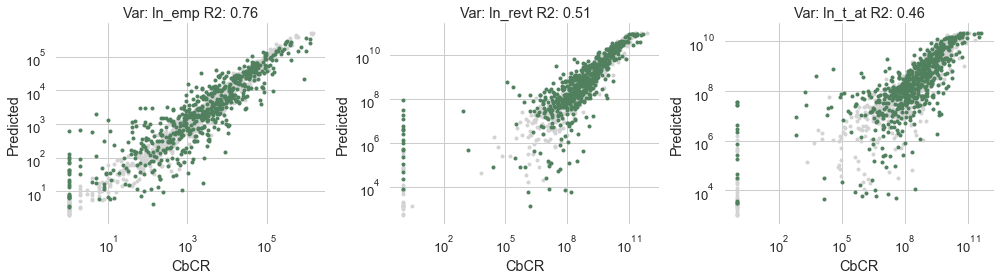

In [23]:
plt.figure(figsize=(14,4))
for i,var in enumerate(["ln_emp","ln_revt","ln_t_at"]):
    est = HistGradientBoostingRegressor(**metaparameters[var])#(alpha=0.03)
    plt.subplot(1,3,i+1)
    plot_r2(est,df_foreign.dropna(subset=[var]),var)

plt.tight_layout()    
plt.savefig(f"{path_figures}predicted_emp_revt.pdf")

## All pieces together

In [24]:
cols = ['iso3_o','txc','ln_pi', 'ln_emp', 'ln_revt','ln_t_at','ln_cit_revenue_o', 'gdpcap_ppp_o', 'gatt_o', 'wto_o', 'entry_proc_o', 'entry_time_o', 'entry_tp_o', 'Physicians_per_1000_wb_o', 'Nurses_per_1000_wb_o', 'region_tjn_o', 'EU28_o', 'OECD_o', 'UKt_o', 'cit_o', 'ratings_o', 'english_o', 'Total FSI_o', 'ln_accountant_o', 'ln_all_tax_o', 'ln_banker_o', 'ln_ceo_o', 'ln_cfo_o', 'ln_coo_o', 'ln_cxo_o', 'ln_engineer_o', 'ln_other_corporate_o', 'ln_physician_o', 'ln_tax_compliance_audit_o', 'ln_transfer_pricing_o', 'ln_wealth_o', 'ln_audience_o', 'ln_consumption_o', 'ln_gfcf_o', 'ln_population_o', 'ln_uhnwi_o', 'ln_BIS_o', 'ln_finance_o', 'governance_o', 'ln_gdppc_o', 'tax_complex_o', 'cthi_o', 'etr_real_o', 'ln_etr_real_o', 'ln_pop_o', 'ln_gdp_o', 'ln_gdpcap_o', 'ln_gdp_ppp_o', 'ln_pop_pwt_o', 'ln_gdp_ppp_pwt_o', 'ln_entry_cost_o', 'ln_IP_payments_wb_o', 'ln_IP_receipts_wb_o', 'ln_FDI_inflows_WDI_wb_o', 'ln_Total_reserves_wb_o', 'ln_Number_of_new_businesses_registered_wb_o', 'ln_Imports_wb_o', 'ln_Exports_wb_o', 'ln_GDP_pc_wb_o', 'ln_GDP_deflator_wb_o', 'ln_Govt_exp_educ_gdp_wb_o', 'ln_Health_exp_gdp_wb_o', 'ln_GreenfieldFDI_outward_o', 'ln_GreenfieldFDI_inward_o', 'ln_resource_taxes_o', 'ln_total_taxes_revenue_o', 'ln_who_gvt_health_expenditure_o', 'ln_month_wage_o', 'ln_GDP_int_o', 'ln_POP_int_o', 'ln_Physicians_o', 'ln_Nurses_o', 'ln_n_companies_orb_o', 'gdp_ppp_o', 'pop_pwt_o', 'gdp_ppp_pwt_o', 'ln_cit_o']



df_domestic = df_pairs.loc[df_pairs["iso3_o"]==df_pairs["iso3_d"],cols]
df_foreign = df_pairs.loc[df_pairs["iso3_o"]!=df_pairs["iso3_d"]]


[IterativeImputer] Completing matrix with shape (214, 75)
[IterativeImputer] Ending imputation round 1/100, elapsed time 0.46
[IterativeImputer] Change: 715031746.7178155, scaled tolerance: 19605164.963789877 
[IterativeImputer] Ending imputation round 2/100, elapsed time 0.89
[IterativeImputer] Change: 48599355.92986615, scaled tolerance: 19605164.963789877 
[IterativeImputer] Ending imputation round 3/100, elapsed time 1.34
[IterativeImputer] Change: 89806.89461148508, scaled tolerance: 19605164.963789877 
[IterativeImputer] Early stopping criterion reached.
[IterativeImputer] Completing matrix with shape (214, 75)
[IterativeImputer] Ending imputation round 1/3, elapsed time 0.01
[IterativeImputer] Ending imputation round 2/3, elapsed time 0.03
[IterativeImputer] Ending imputation round 3/3, elapsed time 0.05
ln_pi 0.8825847626937482
ln_emp 0.9635643016380011
ln_revt 0.8406382460348585
ln_t_at 0.9002798311172503


,ln_pi,ln_emp,ln_revt,ln_t_at
index,,,,
ln_BIS_o,0.133627,-0.106024,-0.045950,0.225357
ln_GDP_int_o,0.428832,0.517365,0.446227,-0.128295
ln_POP_int_o,0.030015,0.380814,-0.107823,0.269412
etr_real_o,-0.706927,-0.255366,3.637298,2.414948
ln_n_companies_orb_o,0.732548,0.509870,1.032782,0.914951


(10000000.0, 2000000000000.0)

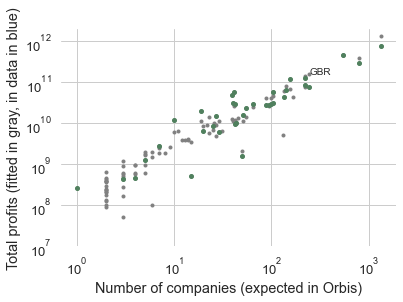

In [25]:
# #Predict domestic
# vars_use = df_domestic.count()
# vars_use = list(vars_use[vars_use>=len(df_domestic)*3/4].index)
# vars_use = [_ for _ in vars_use if "region" not in _]
vars_use = np.array(df_domestic.columns)[df_domestic.dtypes!=object]
vars_use = [_ for _ in vars_use if (_ not in df_fin.columns) and (_[3:] not in df_fin.columns)]

# vars_use = ['Physicians_per_1000_o', 'Nurses_per_1000_o', 'EU28_o', 'OECD_o', 'UKt_o', 'cit_o', 'ln_cit_o', 'ratings_o', 'english_o', 'Total FSI_o', 'ln_accountant_o', 'ln_all_tax_o', 'ln_banker_o', 'ln_ceo_o', 'ln_cfo_o', 'ln_coo_o', 'ln_cxo_o', 'ln_engineer_o', 'ln_other_corporate_o', 'ln_physician_o', 'ln_tax_compliance_audit_o', 'ln_transfer_pricing_o', 'ln_wealth_o', 'ln_audience_o', 'ln_consumption_o', 'ln_gfcf_o', 'ln_population_o', 'ln_uhnwi_o', 'ln_BIS_o', 'ln_finance_o', 'governance_o', 'ln_gdppc_o', 'tax_complex_o', 'cthi_o', 'etr_real_o', 'ln_etr_real_o', 'ln_pop_o', 'ln_gdp_o', 'ln_gdpcap_o', 'ln_entry_cost_o', 'ln_month_wage_o', 'ln_Health_expenditure_gdp_o', 'ln_govt_exp_educ_sgdp_wb_o', 'ln_resource_taxes_o', 'ln_total_taxes_revenue_o', 'ln_GDP_int_o', 'ln_POP_int_o', 'ln_Physicians_o', 'ln_Nurses_o', 'ln_etr_real_o', 'ln_n_companies_orb_o', 'ln_FDI_Inflows_WDI_o', 'ln_imports_wbd_o', 'ln_exports_wbd_o', 'ln_ip_payments_wbd_o', 'ln_ip_receipts_wbd_o']
dfx = impute(df_domestic,vars_use,verbose=5)
df_domestic_filled = fill_domestic(dfx,bootstrap=False,output=True,
                    columns =["ln_BIS_o","ln_GDP_int_o","ln_POP_int_o", "etr_real_o","ln_n_companies_orb_o"])

v = "ln_n_companies_orb_o"
for c,x,y in zip(df_domestic_filled["iso3_o"],np.exp(df_domestic_filled[v]),np.exp(df_domestic_filled["fitted_ln_pi"])):
    if c == "GBR":
        plt.annotate(c,(x,y))
plt.plot(np.exp(df_domestic_filled[v]),np.exp(df_domestic_filled["fitted_ln_pi"]),".",color="gray")
plt.plot(np.exp(df_domestic_filled[v]),np.exp(df_domestic_filled["ln_pi"]),".",ms=8)
plt.xscale("log")
plt.yscale("log")
sns.despine(bottom=True,left=True)
plt.xlabel("Number of companies (expected in Orbis)")
plt.ylabel("Total profits (fitted in gray, in data in blue)")
plt.ylim(1E7,2E12)

Predictions for NLDs


,iso3_o,iso3_d,emp,pi,txc,revt,t_at,etr,ln_pi,ln_revt,ln_emp
1806,NLD,FJT,3513906.0,8.200579e+10,2.028877e+10,1.519187e+12,8.259508e+11,0.247407,25.130056,28.049197,15.072239
1807,NLD,NLD,554101.0,3.034746e+10,2.149026e+09,2.669964e+11,1.114152e+11,0.070814,24.135979,26.310501,13.225104


,fitted_ln_pi,fitted_ln_emp,fitted_ln_revt,fitted_ln_t_at,ln_pi,ln_emp,ln_revt,ln_t_at
39130,4.042052e+10,627623.627972,2.428075e+11,2.267922e+11,3.034746e+10,554102.0,2.669964e+11,1.114152e+11


fitted_ln_pi      1.130428e+11
fitted_ln_emp     2.469647e+06
fitted_ln_revt    8.131655e+11
fitted_ln_t_at    3.243570e+11
dtype: float64

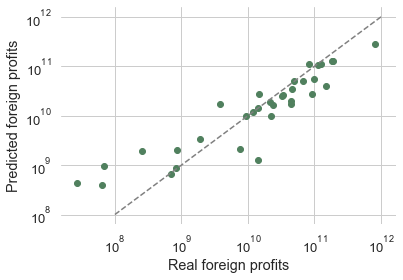

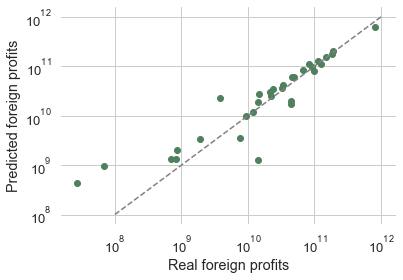

<ipython-input-16-19406520277f>:61: RuntimeWarning: divide by zero encountered in double_scalars
  scale_by = pred.sum().values/truth.values
<ipython-input-16-19406520277f>:61: RuntimeWarning: divide by zero encountered in true_divide
  scale_by = pred.sum().values/truth.values
<ipython-input-16-19406520277f>:62: RuntimeWarning: invalid value encountered in less
  scale_by[truth.values<0] = np.inf
<ipython-input-16-19406520277f>:61: RuntimeWarning: invalid value encountered in double_scalars
  scale_by = pred.sum().values/truth.values
<ipython-input-16-19406520277f>:61: RuntimeWarning: invalid value encountered in true_divide
  scale_by = pred.sum().values/truth.values


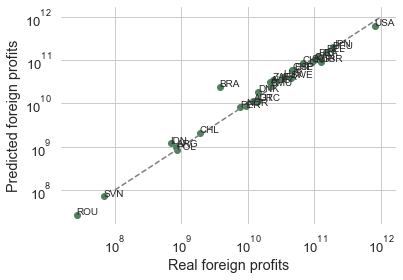

In [26]:

#Predict foreign
df_foreign_filled = fill_foreign(df_foreign,bootstrap=False,output=False)


#Check e.g. NLD
ground = df_fin.loc[df_fin["iso3_o"]=="NLD"]
for var in ["pi","revt","emp"]:
    ground["ln_"+var] = np.log(1+ground[var])
    
print("Predictions for NLDs")
display(ground)
display(np.exp(df_domestic_filled.loc[df_domestic_filled["iso3_o"]=="NLD",["fitted_ln_pi","fitted_ln_emp","fitted_ln_revt","fitted_ln_t_at","ln_pi","ln_emp","ln_revt","ln_t_at"]]))
foreign_nl = df_foreign_filled.loc[df_foreign_filled["iso3_o"]=="NLD",["fitted_ln_pi","fitted_ln_emp","fitted_ln_revt","fitted_ln_t_at"]]
display(np.exp(foreign_nl).sum().T)

# x = df_foreign_filled.loc[(df_foreign_filled["iso3_o"]=="NLD")&(df_foreign_filled["iso3_d"]!="NLD"),["fitted_ln_pi","fitted_ln_emp","fitted_ln_revt"]]
# print(np.exp(x["fitted_ln_pi"]-1).sum()/1E9)

plot_matching_foreign(df_fin,df_foreign_filled)

##Fix the ones we know
for var in ["ln_pi","ln_revt","ln_emp","ln_t_at"]:
    df_foreign_filled.loc[~np.isnan(df_foreign_filled[var]),"fitted_"+var] = df_foreign_filled.loc[~np.isnan(df_foreign_filled[var]),var] 
    df_domestic_filled.loc[~np.isnan(df_domestic_filled[var]),"fitted_"+var] = df_domestic_filled.loc[~np.isnan(df_domestic_filled[var]),var] 
    

    #countries with no companies
    df_domestic_filled.loc[(df_domestic_filled["ln_n_companies_orb_o"]==0),"fitted_"+var] = 0
    df_foreign_filled.loc[df_foreign_filled["ln_n_companies_orb_o"]==0,"fitted_"+var] = 0

# x = df_foreign_filled.loc[(df_foreign_filled["iso3_o"]=="NLD")&(df_foreign_filled["iso3_d"]!="NLD"),["fitted_ln_pi","fitted_ln_emp","fitted_ln_revt"]]
# print(np.exp(x["fitted_ln_pi"]-1).sum()/1E9)

plot_matching_foreign(df_fin,df_foreign_filled)

df_foreign_filled = [adjust_total(*_) for _ in df_foreign_filled.groupby("iso3_o")]
df_foreign_filled = pd.concat(df_foreign_filled)

# x = df_foreign_filled.loc[(df_foreign_filled["iso3_o"]=="NLD")&(df_foreign_filled["iso3_d"]!="NLD"),["fitted_ln_pi","fitted_ln_emp","fitted_ln_revt"]]
# print(np.exp(x["fitted_ln_pi"]-1).sum()/1E9)

#small differences because we took out double counting
#data of brazil for FJT wrong (it does not affect the data, only this comparison)
plot_matching_foreign(df_fin,df_foreign_filled,annot=True)

for var in ["ln_pi","ln_revt","ln_emp","ln_t_at"]:
    df_foreign_filled.loc[:,var[3:]] = np.exp(df_foreign_filled["fitted_"+var])-1
    df_domestic_filled.loc[:,var[3:]] = np.exp(df_domestic_filled["fitted_"+var])-1
    

# 4 Bootsrap

In [27]:
def one_boot():
    """
    Fit the model
    
    Requires as global variables:
    - df_domestic
    - df_foreign
    - df_fin_mis
    - df_dom_remaining
    """
    
    ## DOMESTIC: Impute domestic data and fit model
    vars_use = np.array(df_domestic.columns)[df_domestic.dtypes!=object]
    vars_use = [_ for _ in vars_use if (_ not in df_fin.columns) and (_[3:] not in df_fin.columns)]

    dfx = impute(df_domestic,vars_use)
    df_domestic_filled = fill_domestic(dfx,bootstrap=True,output=False,
                        columns =["ln_BIS_o","ln_GDP_int_o","ln_POP_int_o", "etr_real_o","ln_n_companies_orb_o"])

    ## FOREIGN: 
    # Impute fireign data and fit model
    df_foreign_filled = fill_foreign(df_foreign,bootstrap=True,output=False)

    
    # Correct the information that we know from the raw data
    for var in ["ln_pi","ln_revt","ln_emp","ln_t_at"]:
        df_foreign_filled.loc[~np.isnan(df_foreign_filled[var]),"fitted_"+var] = df_foreign_filled.loc[~np.isnan(df_foreign_filled[var]),var] 
        df_domestic_filled.loc[~np.isnan(df_domestic_filled[var]),"fitted_"+var] = df_domestic_filled.loc[~np.isnan(df_domestic_filled[var]),var] 

        #companies with no companies have no profits/etc
        df_domestic_filled.loc[(df_domestic_filled["ln_n_companies_orb_o"]==0),"fitted_"+var] = 0
        df_foreign_filled.loc[df_foreign_filled["ln_n_companies_orb_o"]==0,"fitted_"+var] = 0

    # Adjust the totals to match the groups
    df_foreign_filled = [adjust_total(*_) for _ in df_foreign_filled.groupby("iso3_o")]
    df_foreign_filled = pd.concat(df_foreign_filled)

    ## CREATE DATASET
    # Calculate the numbers from the logs
    for var in ["ln_pi","ln_revt","ln_emp","ln_t_at"]:
        df_foreign_filled.loc[:,var[3:]] = np.exp(df_foreign_filled["fitted_"+var])-1
        df_domestic_filled.loc[:,var[3:]] = np.exp(df_domestic_filled["fitted_"+var])-1

    # Use only the domestic data of the countries we have no information
    df_dom_remaining = df_domestic_filled.loc[~df_domestic_filled["iso3_o"].isin(df_fin_mis["iso3_o"].unique())]

    # Merge the domestic data to the raw data
    df_calculate_mis = pd.concat([df_fin_mis,df_dom_remaining],sort=False)
    
    # Specify which raws correspond to domestic data
    df_calculate_mis["Domestic"] = (df_calculate_mis["iso3_o"]==df_calculate_mis["iso3_d"]).astype(int)

    
    ## ADJUST DATASET
    # Calculate the sum by destination country in the raw data
    df_mialignment = df_calculate_mis.copy()
    for var in ["emp","revt","t_at"]:
        df_mialignment[f"raw_{var}_sum"] = df_mialignment.groupby(["iso3_d","Domestic"])[var].transform(np.sum)
        df_mialignment[f"{var}_pred"] = df_mialignment[f"{var}"].copy()
    
    # Calculate the sum by destination country in the predicted data
    pred = df_foreign_filled.groupby("iso3_d")[["emp","revt","t_at"]].sum()
    pred.columns = ["emp_pred_sum","revt_pred_sum","t_at_pred_sum"]
    
    # Merge both to adjust
    pred = pd.merge(df_mialignment,pred.reset_index(),how="outer")   
    
    # Calculate the ratio between predicted and raw, and keep the lowest of the two values
    pred["extra_emp"] = (pred["emp_pred_sum"]+1)/(pred["raw_emp_sum"]+1).round(2)
    pred["extra_revt"] = (pred["revt_pred_sum"]+1)/(pred["raw_revt_sum"]+1).round(2)
    pred["one"] = 1
    pred["extra_top"] = pred[["one","extra_emp","extra_revt"]].max(1)
    pred["extra_max"] = pred[["extra_emp","extra_revt"]].max(1)    
    pred["extra"] = pred[["extra_emp","extra_revt"]].min(1)
    # If max is <1 don't adjust
    pred.loc[pred['extra_top']==1,"extra"] = pred.loc[pred['extra_top']==1,"extra_max"]
    # If max is >1 and min <1
    pred.loc[(pred['extra_max']>1)&(pred['extra']<1),"extra"] = 1
    # Cap the adjustment to 10
    pred.loc[pred["extra"]>10,"extra"] = 10#np.nan#Capped at 10 times 10# np.nan #Will remove that observation (during the correction step) when we are not capturing almost anything in the data
    # Don't adjust domestic data    
    pred.loc[pred["Domestic"]==1,"extra"] = 1
    
    # Perform adjustment
    pred["profits"] = pred["pi"]*pred["extra"]
    for var in ["emp","revt","t_at"]:
        pred[f"{var}_pred"] *= pred["extra"]
    
    # Return data
    return pred[["iso3_d","iso3_o","Domestic","emp_pred","revt_pred","t_at_pred","profits","extra","emp","revt","t_at","pi"]]


In [28]:

iso3_to_wages = pickle.load(open(iso3_to_wages_output,"rb+"))
iso3_to_cit = pickle.load(open(iso3_to_cit_output,"rb+"))

In [29]:
#Test with one ereplicate to see if everything looks okay
with np.errstate(divide='ignore', invalid='ignore'):
    r = one_boot()
iso3_to_dict = df_etrs.set_index("Unnamed: 0")["ETR_total"].to_dict()
print(iso3_to_dict["HUN"])
r["etr"] = r["iso3_d"].map(iso3_to_dict)
r["wages"] = r["iso3_d"].map(iso3_to_wages)*r["emp"]
r["wages_pred"] = r["iso3_d"].map(iso3_to_wages)*r["emp_pred"]

df_mialignmentx = calculate_misalignment(r,
                                          pi_var="profits",
                           weights=[0,1/2,0,1/2],
                                          weights_var = ["revt_pred","emp_pred","t_at_pred","wages"]
                    )

r = df_mialignmentx.sort_values(by="misaligned_profits")
display(r.head(15))
display(r.tail(15))

0.2413435007845258
Profit shifted 1411.6 adjusted to 1287.2


,iso3_d,iso3_o,Domestic,emp_pred,revt_pred,t_at_pred,profits,extra,emp,revt,t_at,pi,etr,wages,wages_pred,share_emp_pred,share_wages,share_economy,share_profits,pi_theo_mis,misaligned_profits
238,USA,USA,1,2.290346e+07,1.061798e+13,5.538479e+12,7.669906e+11,1.000000,22903463.0,1.061798e+13,5.538479e+12,7.669906e+11,0.227774,9.289645e+10,9.289645e+10,0.161515,0.305927,0.233721,0.164037,1.092814e+12,-2.970970e+11
551,FRA,FRA,1,3.483270e+06,1.065361e+12,6.744853e+11,6.655499e+10,1.000000,3483270.0,1.065361e+12,6.744853e+11,6.655499e+10,0.250294,1.243829e+10,1.243829e+10,0.024564,0.040962,0.032763,0.014234,1.531901e+11,-7.899698e+10
476,DEU,DEU,1,4.012874e+06,1.567488e+12,1.087355e+12,1.304950e+11,1.000000,4012874.0,1.567488e+12,1.087355e+12,1.304950e+11,0.182753,1.880753e+10,1.880753e+10,0.028299,0.061937,0.045118,0.027909,2.109586e+11,-7.336954e+10
571,GBR,GBR,1,3.196208e+06,1.100918e+12,8.732293e+11,7.816987e+10,1.000000,3196208.0,1.100918e+12,8.732293e+11,7.816987e+10,0.073272,1.033137e+10,1.033137e+10,0.022540,0.034023,0.028282,0.016718,1.322362e+11,-4.929959e+10
753,JPN,JPN,1,9.482953e+06,4.390036e+12,2.211580e+12,2.985339e+11,1.000000,9482953.0,4.390036e+12,2.211580e+12,2.985339e+11,0.274194,2.443718e+10,2.443718e+10,0.066874,0.080477,0.073675,0.063848,3.444844e+11,-4.189923e+10
566,GBR,CHN,0,9.075030e+05,8.420035e+10,1.475797e+10,1.912740e+09,1.067820,849865.0,7.885255e+10,1.382065e+10,1.791257e+09,0.073272,2.747089e+09,2.933397e+09,0.006400,0.009047,0.007723,0.000409,3.611158e+10,-3.118371e+10
580,GBR,USA,0,1.295060e+06,5.196605e+11,4.550747e+11,1.932109e+10,1.067820,1212807.0,4.866554e+11,4.261716e+11,1.809396e+10,0.073272,3.920257e+09,4.186129e+09,0.009133,0.012910,0.011021,0.004132,5.153334e+10,-2.937226e+10
686,IND,IND,1,4.162272e+06,6.044629e+11,9.601801e+11,4.482289e+10,1.000000,4162272.0,6.044629e+11,9.601801e+11,4.482289e+10,0.417350,8.595380e+08,8.595380e+08,0.029352,0.002831,0.016092,0.009586,7.523922e+10,-2.773467e+10
486,DEU,USA,0,7.234811e+05,2.794512e+11,1.007509e+11,8.757714e+09,1.285026,563009.0,2.174674e+11,7.840379e+10,6.815205e+09,0.182753,2.638710e+09,3.390810e+09,0.005102,0.008690,0.006896,0.001873,3.224328e+10,-2.141496e+10
573,GBR,IND,0,9.310965e+04,1.641408e+10,1.235861e+10,-1.860867e+10,1.067820,87196.0,1.537158e+10,1.157368e+10,-1.742678e+10,0.073272,2.818509e+08,3.009660e+08,0.000657,0.000928,0.000792,-0.003980,3.705042e+09,-2.034642e+10


,iso3_d,iso3_o,Domestic,emp_pred,revt_pred,t_at_pred,profits,extra,emp,revt,t_at,pi,etr,wages,wages_pred,share_emp_pred,share_wages,share_economy,share_profits,pi_theo_mis,misaligned_profits
1687,IRQ,CHE,0,NaN,3.101504e+08,4.441442e+08,-2.811124e+07,1.984870,NaN,156257277.0,223764887.0,-14162762.0,0.078822,NaN,NaN,NaN,NaN,NaN,-6.012185e-06,NaN,NaN
1696,JOR,CHE,0,NaN,9.712707e+08,2.109494e+08,5.946583e+07,4.609465,NaN,210712229.0,45764389.0,12900809.0,0.161232,NaN,NaN,NaN,NaN,NaN,1.271803e-05,NaN,NaN
1706,LBN,CHE,0,NaN,6.116982e+08,1.501875e+08,4.828772e+07,2.682084,NaN,228068283.0,55996589.0,18003807.0,0.127102,NaN,NaN,NaN,NaN,NaN,1.032735e-05,NaN,NaN
1724,LKA,MEX,0,NaN,0.000000e+00,NaN,0.000000e+00,1.548102,NaN,0.0,NaN,0.0,0.128095,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN
1729,LTU,CHE,0,NaN,6.305596e+08,1.060677e+08,1.995264e+07,2.184844,NaN,288606265.0,48547027.0,9132295.0,0.150372,NaN,NaN,NaN,NaN,NaN,4.267294e-06,NaN,NaN
1742,LVA,CHE,0,NaN,1.699368e+08,4.546641e+07,5.988331e+06,1.743227,NaN,97483993.0,26081748.0,3435198.0,0.135916,NaN,NaN,NaN,NaN,NaN,1.280731e-06,NaN,NaN
1755,MCO,CHE,0,NaN,3.624914e+08,6.393290e+07,7.983444e+07,1.235476,NaN,293402275.0,51747593.0,64618372.0,0.124525,NaN,NaN,NaN,NaN,NaN,1.707429e-05,NaN,NaN
1762,MKD,CHE,0,NaN,5.349737e+07,1.436013e+07,5.308105e+06,1.318619,NaN,40570771.0,10890284.0,4025504.0,0.128199,NaN,NaN,NaN,NaN,NaN,1.135251e-06,NaN,NaN
1794,SEN,CHE,0,NaN,1.302169e+08,7.011357e+07,1.215749e+05,1.192718,NaN,109176630.0,58784709.0,101931.0,0.139571,NaN,NaN,NaN,NaN,NaN,2.600137e-08,NaN,NaN
1807,SLV,CHE,0,NaN,1.199626e+08,1.328578e+07,7.702039e+06,1.222834,NaN,98102132.0,10864741.0,6298515.0,0.219190,NaN,NaN,NaN,NaN,NaN,1.647244e-06,NaN,NaN


In [31]:
# 1000 replicates
with np.errstate(divide='ignore', invalid='ignore'), open(final_data_output,"w+") as f:
    for i in range(1000):
        print(i+1, end=": ")
        pred = one_boot()
        pred["n_rep"] = i
        
        pred.to_csv(f,sep="\t",index = None,header = i==0)



1: 2: 3: 4: 5: 6: 7: 8: 9: 10: 11: 12: 13: 14: 15: 16: 17: 18: 19: 20: 21: 22: 23: 24: 25: 26: 27: 28: 29: 30: 31: 32: 33: 34: 35: 36: 37: 38: 39: 40: 41: 42: 43: 44: 45: 46: 47: 48: 49: 50: 51: 52: 53: 54: 55: 56: 57: 58: 59: 60: 61: 62: 63: 64: 65: 66: 67: 68: 69: 70: 71: 72: 73: 74: 75: 76: 77: 78: 79: 80: 81: 82: 83: 84: 85: 86: 87: 88: 89: 90: 91: 92: 93: 94: 95: 96: 97: 98: 99: 100: 101: 102: 103: 104: 105: 106: 107: 108: 109: 110: 111: 112: 113: 114: 115: 116: 117: 118: 119: 120: 121: 122: 123: 124: 125: 126: 127: 128: 129: 130: 131: 132: 133: 134: 135: 136: 137: 138: 139: 140: 141: 142: 143: 144: 145: 146: 147: 148: 149: 150: 151: 152: 153: 154: 155: 156: 157: 158: 159: 160: 161: 162: 163: 164: 165: 166: 167: 168: 169: 170: 171: 172: 173: 174: 175: 176: 177: 178: 179: 180: 181: 182: 183: 184: 185: 186: 187: 188: 189: 190: 191: 192: 193: 194: 195: 196: 197: 198: 199: 200: 201: 202: 203: 204: 205: 206: 207: 208: 209: 210: 211: 212: 213: 214: 215: 216: 217: 218: 219: 220: 221: 222